# ASSIGNMENT 10
## Comparing GAN and VAE Using Experimental Results

**Name:** Bhumika R   
**Course:** BCA  
**Subject:** Generative AI

### Objective
The objective of this assignment is to compare a GAN and a VAE using the practical results obtained in the previous assignments. The comparison focuses on image quality, diversity, realism, training stability, controllability, mode collapse, and suitable applications.

## 1. Experimental Setup

The results used in this assignment come from the previous practical experiments:

- **GAN:** DCGAN trained on **Fashion-MNIST**
- **VAE:** VAE trained on **MNIST**
- Both experiments use 28 × 28 grayscale images, but the datasets are different. Therefore, this is a practical comparison of the two models based on the outputs already obtained, rather than a perfectly controlled benchmark.

### GAN experiment
The DCGAN used a noise vector of size 100, batch size 128 and 25 training epochs. Generated samples were saved during training.

### VAE experiment
The VAE used a 2-dimensional latent space and was trained for 20 epochs. The model generated MNIST digits from random latent vectors and also supported decoding points from the latent space.

## 2. Recorded Training Results

The values below are taken from the previous notebooks.

**DCGAN final epoch:** Generator loss = **0.7495**, Discriminator loss = **1.3420**.

**VAE final epoch:** Total loss = **140.7854**, Reconstruction loss = **134.1865**, KL loss = **6.5989**.

The GAN losses fluctuate because the Generator and Discriminator are competing objectives. The VAE reconstruction loss decreases steadily during training, while the KL term remains relatively small and increases gradually.

In [8]:
# Enter the final values recorded from the previous assignments

results = {
    "Model": ["DCGAN (GAN)", "VAE"],
    "Dataset": ["Fashion-MNIST", "MNIST"],
    "Epochs": [25, 20],
    "Final Generator Loss": [0.7495, None],
    "Final Discriminator Loss": [1.3420, None],
    "Final Total Loss": [None, 140.7854],
    "Final Reconstruction Loss": [None, 134.1865],
    "Final KL Loss": [None, 6.5989]
}

import pandas as pd
pd.DataFrame(results)

,Model,Dataset,Epochs,Final Generator Loss,Final Discriminator Loss,Final Total Loss,Final Reconstruction Loss,Final KL Loss
0,DCGAN (GAN),Fashion-MNIST,25,0.7495,1.342,NaN,NaN,NaN
1,VAE,MNIST,20,NaN,NaN,140.7854,134.1865,6.5989


## 3. Upload and Select Approximately 8 Generated Images

You do **not** need Google Drive. In the next cell, use the **Choose Files** option to upload:

1. Your GAN-generated image/grid
2. Your VAE-generated image/grid

The uploaded images will be displayed below and used for the comparison.


Upload your GAN-generated image first (PNG/JPG)


Saving gan_epoch25_grid.png to gan_epoch25_grid (1).png
GAN image uploaded successfully!

 Now upload your VAE-generated image (PNG/JPG)


Saving vae_random_grid.png to vae_random_grid (1).png
 VAE image uploaded successfully!

 Both images are ready for the comparison.


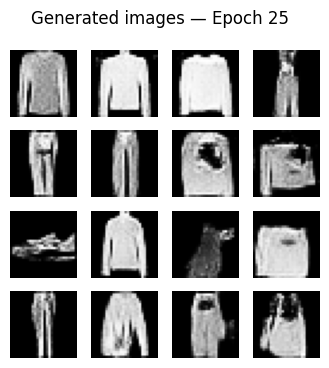

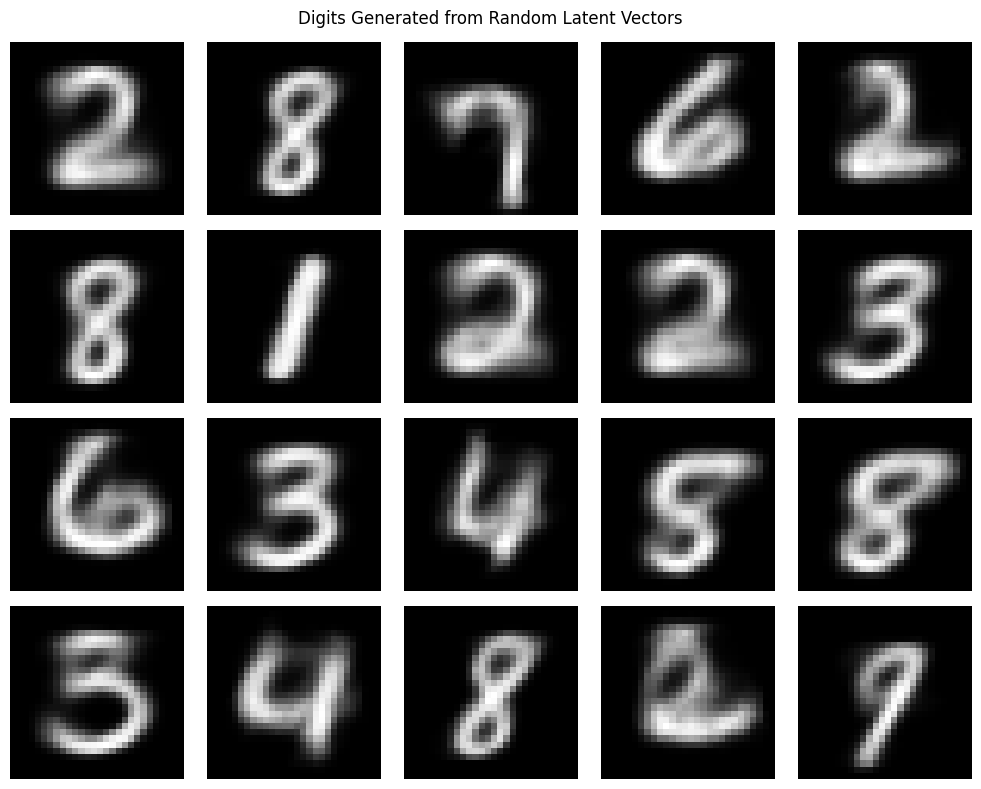

In [9]:
from google.colab import files
from IPython.display import display, Image as IPImage
import os

print("Upload your GAN-generated image first (PNG/JPG)")
gan_upload = files.upload()

gan_file = next(iter(gan_upload))
os.rename(gan_file, "/content/gan_epoch25_grid.png")
print("GAN image uploaded successfully!")

print("\n Now upload your VAE-generated image (PNG/JPG)")
vae_upload = files.upload()

vae_file = next(iter(vae_upload))
os.rename(vae_file, "/content/vae_random_grid.png")
print(" VAE image uploaded successfully!")

print("\n Both images are ready for the comparison.")
display(IPImage(filename="/content/gan_epoch25_grid.png", width=350))
display(IPImage(filename="/content/vae_random_grid.png", width=350))


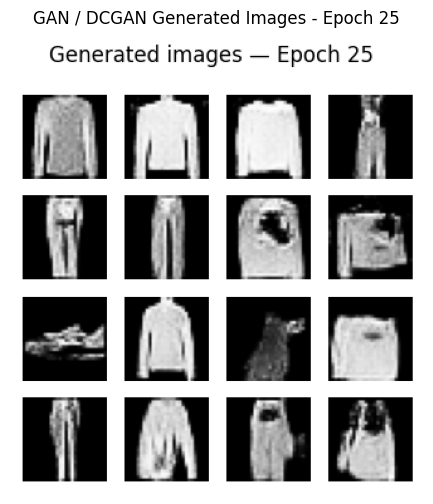

In [6]:
# Display the GAN-generated images

from PIL import Image
import matplotlib.pyplot as plt

gan_img = Image.open("/content/gan_epoch25_grid.png")

plt.figure(figsize=(6, 6))
plt.imshow(gan_img)
plt.title("GAN / DCGAN Generated Images - Epoch 25")
plt.axis("off")
plt.show()

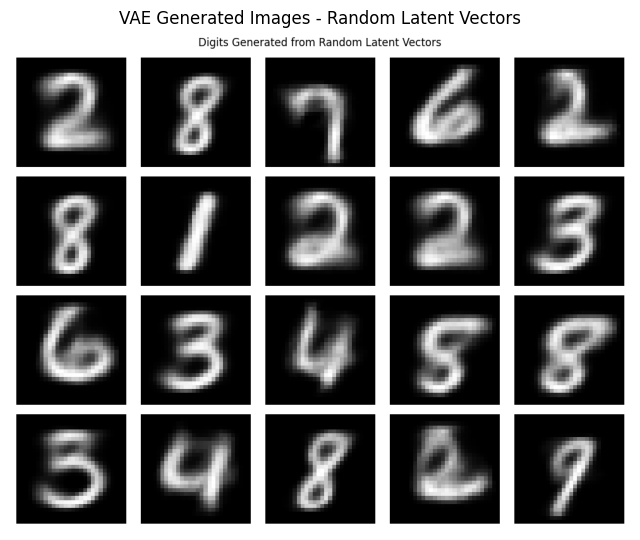

In [7]:
# Display the VAE-generated images

vae_img = Image.open("/content/vae_random_grid.png")

plt.figure(figsize=(8, 7))
plt.imshow(vae_img)
plt.title("VAE Generated Images - Random Latent Vectors")
plt.axis("off")
plt.show()

## 4. Visual Observation

### GAN
The final GAN samples show recognizable clothing-like shapes such as tops, trousers, shoes and bags. Some images are fairly sharp, but several remain blurry or have incomplete shapes. The different samples show reasonable variety, although some outputs are visually similar.

### VAE
The VAE samples clearly resemble handwritten digits. The outputs are smooth and consistent, but their edges are softer than the sharper parts of real MNIST images. Different latent vectors produce different digits, showing good diversity and useful latent-space control.

## 5. Comparison Table

**Rating:** 1 = poor, 5 = excellent.

| Criteria | GAN (DCGAN) | VAE | Observation |
|---|---:|---:|---|
| Image sharpness | 4/5 | 3/5 | GAN outputs have relatively sharper clothing boundaries; VAE outputs are smoother. |
| Diversity | 4/5 | 4/5 | Both produce different samples; VAE latent sampling gives useful variation. |
| Realism | 4/5 | 3/5 | GAN samples can look more realistic, while VAE samples are more blurred. |
| Training stability | 3/5 | 5/5 | GAN training losses fluctuate; VAE training showed a steady decrease in reconstruction/total loss. |
| Ease of controlling output | 3/5 | 5/5 | VAE has an explicit 2-D latent space, making controlled generation easier. |
| Risk of mode collapse | 3/5 | 1/5 | GANs can suffer from mode collapse; no strong collapse is visible in the selected GAN samples. |
| Best practical use | Synthetic image generation | Controlled generation / representation learning | Depends on the task. |

## 6. Training Stability Analysis

The GAN experiment showed fluctuating Generator and Discriminator losses. This is expected because the two networks are trained against each other. The final recorded values were Generator loss **0.7495** and Discriminator loss **1.3420**.

The VAE showed a more predictable optimization pattern. Its final total loss was **140.7854**, with reconstruction loss **134.1865** and KL loss **6.5989**.

Therefore, based on these experiments, the VAE was easier to train and more stable, while the GAN produced sharper-looking image samples.

## 7. Mode Collapse Analysis

Mode collapse happens when a GAN repeatedly generates very similar outputs instead of covering many types of samples.

In the selected DCGAN outputs, different clothing shapes are visible, so there is **no strong evidence of severe mode collapse**. However, some samples have similar visual structures, so a small risk remains.

The VAE does not use the same adversarial training process and therefore does not show the same GAN-style mode-collapse problem.

# 8. Final Verdict

1. Which model would you prefer for generating synthetic training data?
I would prefer the GAN (DCGAN) because it produces more realistic and visually sharper synthetic images and provides good diversity.

2. Which model would you prefer for anomaly detection?
I would prefer the VAE because it provides reconstruction-based analysis and a structured latent representation, making it more suitable for identifying unusual or abnormal samples.

3. Why?
Based on my experimental results, the GAN was better suited for generating realistic synthetic images, while the VAE provided more stable training and useful reconstruction capabilities. Therefore, the choice depends on the application.

## 9. Conclusion

This experiment compared a DCGAN and a VAE using the actual outputs from the previous assignments. The GAN produced recognizable Fashion-MNIST clothing images with relatively good sharpness and realism, but its adversarial training was less stable.

The VAE produced smooth and recognizable MNIST digits and provided a clear 2-D latent space. Its training was more stable and its output was easier to control.

Overall, the choice depends on the application: **GAN is preferred for high-quality synthetic image generation, while VAE is preferred for stable representation learning, reconstruction and anomaly detection.**